# Monte Carlo PnL Simulation

This notebook simulates possible PnL paths by fitting to the historical `pnl` values in a CSV (e.g., `vol_gp\artifacts\variance_proxy_trades.csv`).
The simulation uses **bootstrap resampling** of observed PnL by default, so it matches the empirical distribution.


In [87]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from yfinance_utils import get_history

plt.style.use("seaborn-v0_8")


## Config


In [88]:
CSV_PATH = r"..\return_gp\artifacts\AAPL\return_gp_trades.csv"
SUMMARY_PATH = r"..\return_gp\artifacts\AAPL\return_gp_summary.json"
N_PATHS = 300
N_STEPS = 252
SEED = 7

# Choose how to fit pnl distribution
FIT_METHOD = "normal"  # "bootstrap" or "normal"

# Benchmarks for cumulative PnL comparison
BENCHMARK_TICKER_1 = "SPY"
BENCHMARK_TICKER_2 = "AAPL"


In [89]:
df = pd.read_csv(CSV_PATH)
if "pnl" not in df.columns:
    raise ValueError("CSV must include a \"pnl\" column.")

def resolve_notional(df, summary_path):
    notional = None
    if summary_path and Path(summary_path).exists():
        summary = json.loads(Path(summary_path).read_text(encoding="utf-8"))
        notional = summary.get("notional")
    if notional is None and "notional" in df.columns:
        series = df["notional"].dropna()
        if not series.empty:
            notional = float(series.iloc[0])
    if notional is None:
        raise ValueError("Notional not found. Provide SUMMARY_PATH or a \"notional\" column in the trades CSV.")
    return float(notional)

NOTIONAL = resolve_notional(df, SUMMARY_PATH)

pnl = df["pnl"].dropna().astype(float).to_numpy()
if pnl.size == 0:
    raise ValueError("No pnl values found after dropping NaNs.")

pd.Series(pnl).describe()


count     242.000000
mean       51.517955
std       468.170962
min     -1354.748733
25%      -221.146192
50%        -6.812254
75%       288.736143
max      2274.742914
dtype: float64

In [90]:
rng = np.random.default_rng(SEED)

if FIT_METHOD == "bootstrap":
    # Empirical resampling of observed pnl values
    samples = rng.choice(pnl, size=(N_STEPS, N_PATHS), replace=True)
elif FIT_METHOD == "normal":
    # Parametric fit to mean/std of pnl
    mu = pnl.mean()
    sigma = pnl.std(ddof=1)
    samples = rng.normal(mu, sigma, size=(N_STEPS, N_PATHS))
else:
    raise ValueError("FIT_METHOD must be 'bootstrap' or 'normal'.")

paths = samples.cumsum(axis=0)
paths.shape


(252, 300)

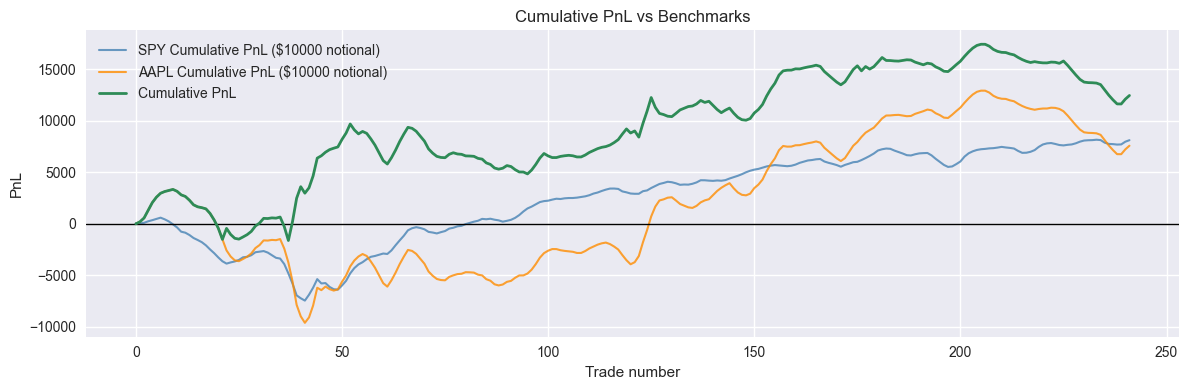

In [91]:
# Plot cumulative PnL and benchmark $ PnL in correct trade order
trade_order = df.copy()
if "trade_date" in trade_order.columns:
    trade_order["trade_date"] = pd.to_datetime(trade_order["trade_date"], errors="coerce")
if "exit_date" in trade_order.columns:
    trade_order["exit_date"] = pd.to_datetime(trade_order["exit_date"], errors="coerce")

sort_cols = [col for col in ["trade_date", "exit_date"] if col in trade_order.columns]
if sort_cols:
    trade_order = trade_order.sort_values(sort_cols, kind="mergesort")

trade_order = trade_order.reset_index(drop=True)
if "pnl" not in trade_order.columns:
    raise ValueError("CSV must include a \"pnl\" column to plot cumulative PnL.")
if "trade_date" not in trade_order.columns or "exit_date" not in trade_order.columns:
    raise ValueError("CSV must include both \"trade_date\" and \"exit_date\" columns to compare with benchmarks.")

if trade_order["trade_date"].isna().any() or trade_order["exit_date"].isna().any():
    raise ValueError("Found NaT in \"trade_date\" or \"exit_date\" after parsing.")

cum_pnl = trade_order["pnl"].astype(float).cumsum()

spy_start = trade_order["trade_date"].min()
spy_end = trade_order["exit_date"].max()

trade_dates = trade_order["trade_date"].dt.normalize()
exit_dates = trade_order["exit_date"].dt.normalize()

def benchmark_cum_pnl(ticker: str, notional: float):
    history = get_history(
        ticker,
        period=None,
        start=str(pd.Timestamp(spy_start).date()),
        end=str((pd.Timestamp(spy_end) + pd.Timedelta(days=1)).date()),
        interval="1d",
        auto_adjust=True,
    )

    close = history["Close"].copy()
    if isinstance(close.index, pd.DatetimeIndex):
        idx = close.index
        if idx.tz is not None:
            idx = idx.tz_localize(None)
        close = close.copy()
        close.index = idx.normalize()
    close = close.sort_index()
    close = close[~close.index.duplicated(keep="last")]

    missing_trade = trade_dates[~trade_dates.isin(close.index)]
    missing_exit = exit_dates[~exit_dates.isin(close.index)]
    if not missing_trade.empty or not missing_exit.empty:
        sample_trade = missing_trade.unique()[:5]
        sample_exit = missing_exit.unique()[:5]
        raise ValueError(
            f"{ticker} history missing required dates (exact match required). "
            f"Missing trade_date count={missing_trade.size}, sample={sample_trade}; "
            f"missing exit_date count={missing_exit.size}, sample={sample_exit}."
        )

    entry_close = close.loc[trade_dates.tolist()].to_numpy()
    exit_close = close.loc[exit_dates.tolist()].to_numpy()
    bench_return = (exit_close / entry_close) - 1.0
    bench_pnl = notional * bench_return
    return bench_pnl.cumsum()

benchmark_1_cum_pnl = benchmark_cum_pnl(BENCHMARK_TICKER_1, NOTIONAL)
benchmark_2_cum_pnl = benchmark_cum_pnl(BENCHMARK_TICKER_2, NOTIONAL)

plt.figure(figsize=(12, 4))
plt.plot(benchmark_1_cum_pnl, color="steelblue", lw=1.5, alpha=0.8,
         label=f"{BENCHMARK_TICKER_1} Cumulative PnL (${NOTIONAL:g} notional)")
plt.plot(benchmark_2_cum_pnl, color="darkorange", lw=1.5, alpha=0.8,
         label=f"{BENCHMARK_TICKER_2} Cumulative PnL (${NOTIONAL:g} notional)")
plt.plot(cum_pnl.to_numpy(), color="seagreen", lw=2.0, zorder=3,
         label="Cumulative PnL")
plt.axhline(0, color="black", lw=1)
plt.title("Cumulative PnL vs Benchmarks")
plt.xlabel("Trade number")
plt.ylabel("PnL")
plt.legend()
plt.tight_layout()


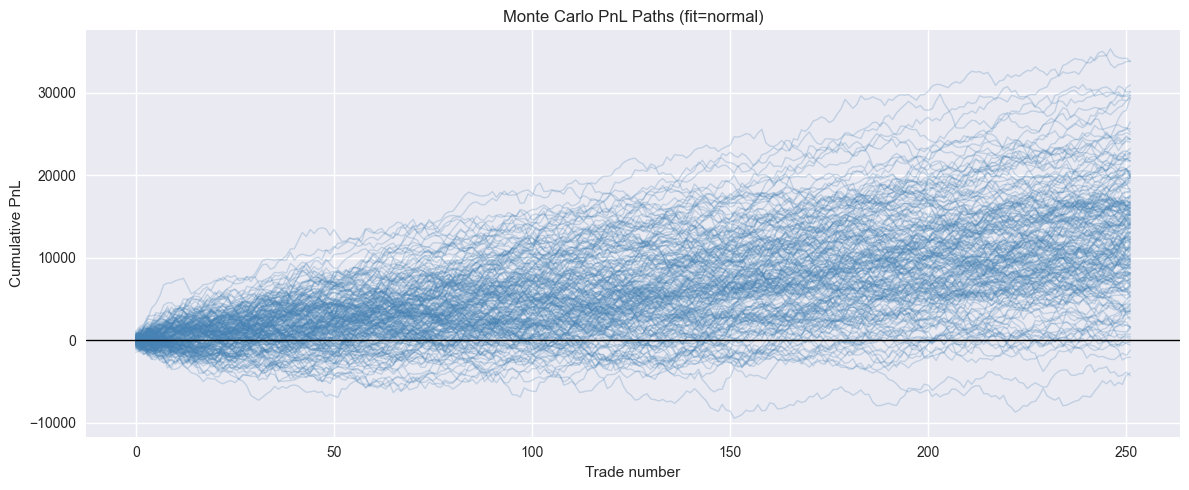

In [92]:
# Plot a subset of cumulative PnL paths
plot_n = min(200, N_PATHS)
idx = rng.choice(N_PATHS, size=plot_n, replace=False)

plt.figure(figsize=(12, 5))
plt.plot(paths[:, idx], color="steelblue", alpha=0.25, lw=1)
plt.axhline(0, color="black", lw=1)
plt.title(f"Monte Carlo PnL Paths (fit={FIT_METHOD})")
plt.xlabel("Trade number")
plt.ylabel("Cumulative PnL")
plt.tight_layout()


count      300.000000
mean     12963.617647
std       7169.026673
min      -4331.688260
25%       8188.399192
50%      13015.620242
75%      16863.327632
max      33778.973480
dtype: float64

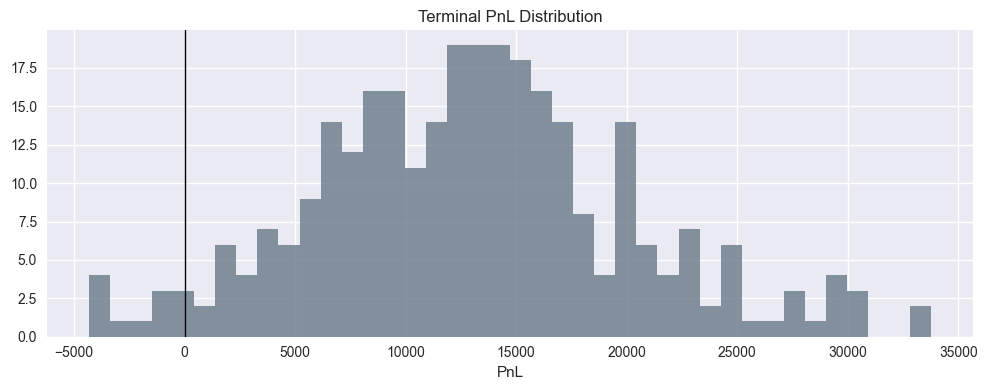

In [93]:
# Terminal PnL distribution
terminal = paths[-1]

plt.figure(figsize=(10, 4))
plt.hist(terminal, bins=40, color="slategray", alpha=0.85)
plt.axvline(0, color="black", lw=1)
plt.title("Terminal PnL Distribution")
plt.xlabel("PnL")
plt.tight_layout()

pd.Series(terminal).describe()
